# Coincall BTCUSD Futures — WebSocket Order Book Capture Analysis

**PS2 · Foundations of Market Microstructure**
*North Carolina State University — Financial Mathematics, Summer 2026*

This notebook performs an in-depth analysis of the live Coincall BTCUSD futures L2 order-book feed
captured via WebSocket. The capture script stores hourly Parquet files with:
- Three timestamps per snapshot: `d_ts` (exchange book-change time), `server_ts` (exchange push time), `recv_ts_ms` (local receipt)
- 100 bid levels and 100 ask levels, each with price and size
- Wide format: one row = one full snapshot

### Sections
| # | Topic |
|---|-------|
| 0 | Load & inventory |
| 1 | Snapshot cadence & feed reliability |
| 2 | Latency chain: `d_ts → server_ts → recv_ts_ms` |
| 3 | Mid-price & bid-ask spread |
| 4 | Price changes & Roll estimator |
| 5 | Book depth (available levels over time) |
| 6 | Average book shape (cumulative depth profile) |
| 7 | Order-book imbalance (OBI) |
| 8 | Tick-size & price-level granularity |
| 9 | Summary |


## Setup

In [24]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

%matplotlib inline

ROOT    = Path("..").resolve()
FIG_DIR = Path(".") / "figures"
OUT_DIR = Path(".") / "output"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

PARQUET_GLOBS = [
    "/Volumes/SEAGATE/Crypto/Coincall_OB/futures_ws/btcusd_20260614_22.parquet",
    str(ROOT / "data/coincall/futures_ws/btcusd_20260614_22.parquet"),
]

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "axes.titlecolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "lines.linewidth":  1.2,
    "figure.dpi":       110,
    "font.size":        9,
    "axes.titlesize":   10,
    "axes.titlepad":    8,
})
C1 = "#58a6ff"   # blue
C2 = "#f78166"   # red-orange
C3 = "#3fb950"   # green
C4 = "#d29922"   # yellow

BID_PX = [f"bid_px_{i:02d}" for i in range(100)]
BID_SZ = [f"bid_sz_{i:02d}" for i in range(100)]
ASK_PX = [f"ask_px_{i:02d}" for i in range(100)]
ASK_SZ = [f"ask_sz_{i:02d}" for i in range(100)]

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight",
                facecolor=plt.rcParams["figure.facecolor"])
    plt.show()


---
## Section 0 — Load & Inventory

Load all captured Parquet files and add derived columns for elapsed time and datetime.


In [25]:
files = []
for g in PARQUET_GLOBS:
    files += [f for f in sorted(glob.glob(g)) if not Path(f).name.startswith("._")]

if not files:
    raise FileNotFoundError("No Coincall parquet files found — is the external drive mounted?")

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df.sort_values("recv_ts_ms", inplace=True)
df.reset_index(drop=True, inplace=True)

df["recv_dt"] = pd.to_datetime(df["recv_ts_ms"], unit="ms", utc=True)
df["t_sec"]   = (df["recv_ts_ms"] - df["recv_ts_ms"].iloc[0]) / 1_000

n_rows = len(df)
span_s = df["t_sec"].iloc[-1]

print(f"Files          : {len(files)}")
print(f"Rows           : {n_rows:,}")
print(f"Columns        : {df.shape[1]}")
print(f"Time span      : {span_s/60:.1f} min  ({span_s:.0f} s)")
print(f"UTC start      : {df['recv_dt'].iloc[0]}")
print(f"UTC end        : {df['recv_dt'].iloc[-1]}")
print(f"BTC mid range  : {df['bid_px_00'].min():.1f} – {df['ask_px_00'].max():.1f} USD")


Files          : 1
Rows           : 8,232
Columns        : 405
Time span      : 60.0 min  (3599 s)
UTC start      : 2026-06-14 22:00:00.224000+00:00
UTC end        : 2026-06-14 22:59:59.084000+00:00
BTC mid range  : 64968.0 – 66793.2 USD


---
## Section 1 — Snapshot Cadence & Feed Reliability

The Coincall WebSocket pushes full L2 snapshots on book changes, not on a fixed timer.
We measure inter-snapshot gaps to characterise the effective update rate and detect
stale periods (large gaps could indicate reconnects or exchange-side throttling).

> **Key question:** Is the feed regular enough for time-series analysis, or does
> irregular cadence require special handling (e.g. resampling)?


In [26]:
gaps_ms = df["recv_ts_ms"].diff().dropna()

cadence = pd.Series({
    "mean_gap_ms":       gaps_ms.mean(),
    "median_gap_ms":     gaps_ms.median(),
    "p95_gap_ms":        gaps_ms.quantile(0.95),
    "p99_gap_ms":        gaps_ms.quantile(0.99),
    "max_gap_ms":        gaps_ms.max(),
    "snapshots_per_sec": 1_000 / gaps_ms.mean(),
}, name="value")

print(cadence.to_string())
cadence.to_frame().T.to_csv(OUT_DIR / "01_cadence_stats.csv", index=False)


mean_gap_ms           437.232414
median_gap_ms         264.000000
p95_gap_ms           1306.000000
p99_gap_ms           2537.300000
max_gap_ms           5618.000000
snapshots_per_sec       2.287113


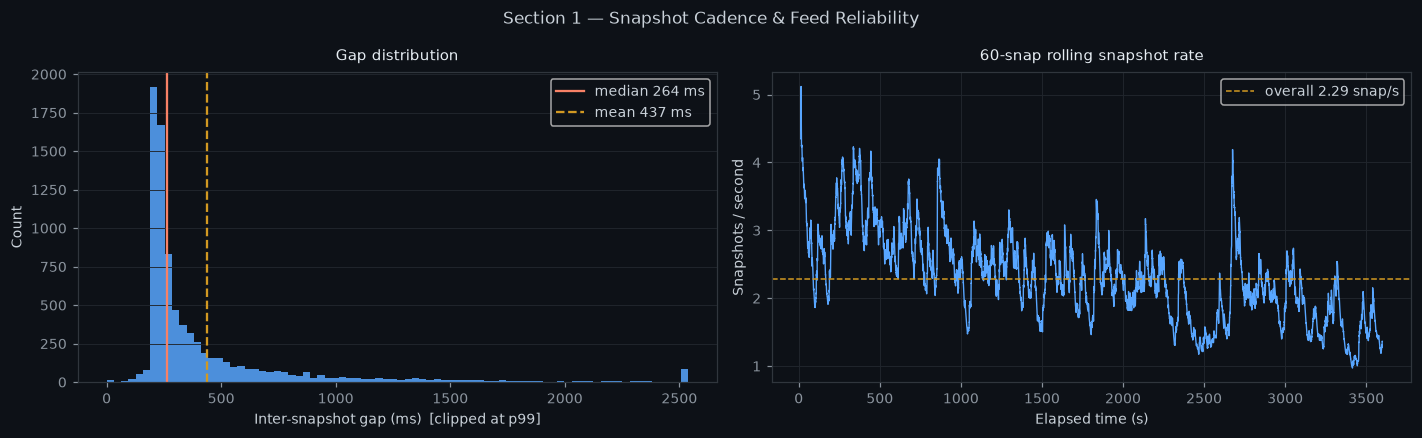

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Section 1 — Snapshot Cadence & Feed Reliability", fontsize=11)

# gap distribution
ax = axes[0]
cap = gaps_ms.clip(upper=gaps_ms.quantile(0.99))
ax.hist(cap, bins=80, color=C1, edgecolor="none", alpha=0.85)
ax.axvline(gaps_ms.median(), color=C2, lw=1.5, label=f"median {gaps_ms.median():.0f} ms")
ax.axvline(gaps_ms.mean(),   color=C4, lw=1.5, ls="--", label=f"mean {gaps_ms.mean():.0f} ms")
ax.set_xlabel("Inter-snapshot gap (ms)  [clipped at p99]")
ax.set_ylabel("Count")
ax.set_title("Gap distribution")
ax.legend(); ax.grid(True, axis="y")

# rolling rate over session
ax = axes[1]
roll_rate = 1_000 / gaps_ms.rolling(60).mean()
ax.plot(df["t_sec"].iloc[1:], roll_rate, color=C1, lw=0.9)
ax.axhline(1_000 / gaps_ms.mean(), color=C4, lw=1, ls="--",
           label=f"overall {1000/gaps_ms.mean():.2f} snap/s")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Snapshots / second")
ax.set_title("60-snap rolling snapshot rate")
ax.legend(); ax.grid(True)

plt.tight_layout()
savefig("01_snapshot_cadence")


---
## Section 2 — Latency Chain: `d_ts → server_ts → recv_ts_ms`

Each WebSocket message carries three timestamps:

| Field | Meaning |
|---|---|
| `d_ts` | When the exchange book state *changed* (µs-precision event time) |
| `server_ts` | When the Coincall server *pushed* the WebSocket message |
| `recv_ts_ms` | When our Python script *received* the message (local wall clock) |

This lets us decompose total end-to-end latency into:
- **Exchange processing lag** = `server_ts − d_ts`
- **Network delivery lag** = `recv_ts_ms − server_ts`
- **End-to-end lag** = `recv_ts_ms − d_ts`

Understanding this pipeline is critical for any live market-making system — the
latency between a real market event and our perception of it bounds our ability
to react to it.


In [28]:
df["lat_exchange_ms"] = df["server_ts"]  - df["d_ts"]
df["lat_network_ms"]  = df["recv_ts_ms"] - df["server_ts"]
df["lat_e2e_ms"]      = df["recv_ts_ms"] - df["d_ts"]

stages = [
    ("lat_exchange_ms", "Exchange (server_ts − d_ts)",     C1),
    ("lat_network_ms",  "Network  (recv_ts  − server_ts)", C2),
    ("lat_e2e_ms",      "End-to-end (recv_ts − d_ts)",     C3),
]

lat_rows = []
for col, label, _ in stages:
    s = df[col]
    lat_rows.append({
        "stage": label,
        "mean_ms":   s.mean(),
        "median_ms": s.median(),
        "p95_ms":    s.quantile(0.95),
        "p99_ms":    s.quantile(0.99),
        "max_ms":    s.max(),
    })
lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv(OUT_DIR / "02_latency_stats.csv", index=False)
print(lat_df.to_string(index=False))


                          stage   mean_ms  median_ms  p95_ms  p99_ms  max_ms
    Exchange (server_ts − d_ts)  0.417031        0.0    1.00    1.00       9
Network  (recv_ts  − server_ts) 86.417638       82.0  102.00  180.69    2217
    End-to-end (recv_ts − d_ts) 86.834670       82.0  102.45  181.00    2218


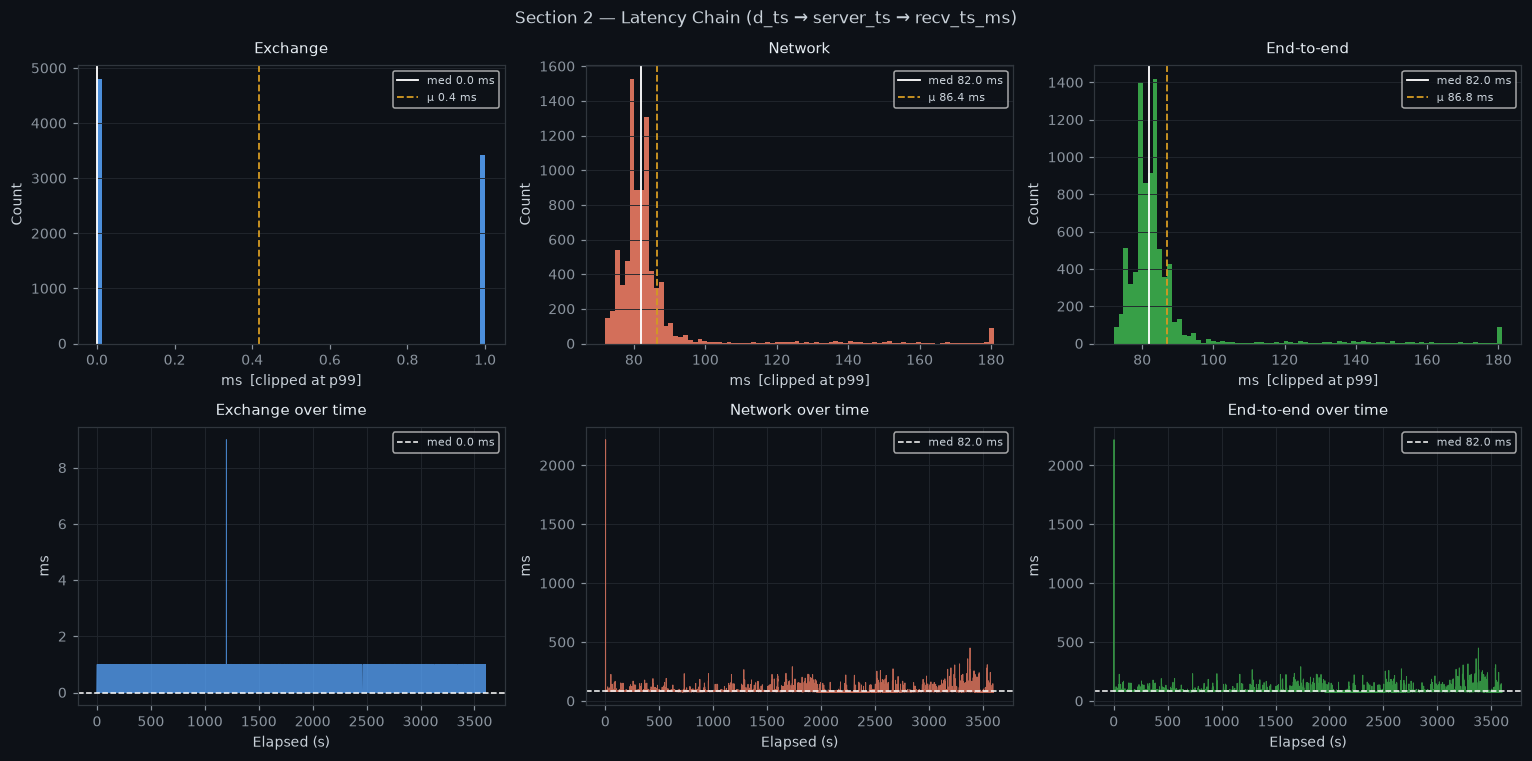

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Section 2 — Latency Chain (d_ts → server_ts → recv_ts_ms)", fontsize=11)

for ci, (col, title, color) in enumerate(stages):
    s      = df[col]
    s_clip = s.clip(upper=s.quantile(0.99))

    ax = axes[0, ci]
    ax.hist(s_clip, bins=80, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(s.median(), color="white", lw=1.2, label=f"med {s.median():.1f} ms")
    ax.axvline(s.mean(),   color=C4,     lw=1.2, ls="--", label=f"μ {s.mean():.1f} ms")
    ax.set_title(title.split("(")[0].strip())
    ax.set_xlabel("ms  [clipped at p99]"); ax.set_ylabel("Count")
    ax.legend(fontsize=7); ax.grid(True, axis="y")

    ax = axes[1, ci]
    ax.plot(df["t_sec"], s, color=color, lw=0.6, alpha=0.75)
    ax.axhline(s.median(), color="white", lw=1, ls="--", label=f"med {s.median():.1f} ms")
    ax.set_title(f"{title.split('(')[0].strip()} over time")
    ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("ms")
    ax.legend(fontsize=7); ax.grid(True)

plt.tight_layout()
savefig("02_latency_chain")


---
## Section 3 — Mid-Price & Bid-Ask Spread

The **mid-price** `m = (best_bid + best_ask) / 2` is the primary price signal.
The **quoted spread** `s = best_ask − best_bid` measures the cost of an immediate round-trip.

For PS2, the quoted spread is the direct, observable benchmark that the Roll estimator
will try to recover from price-change autocorrelation alone.

We also report spread in **basis points** (bps = USD spread / mid × 10,000) for
comparability across price levels.


In [30]:
df["mid"]        = (df["bid_px_00"] + df["ask_px_00"]) / 2
df["spread_abs"] = df["ask_px_00"] - df["bid_px_00"]
df["spread_bps"] = df["spread_abs"] / df["mid"] * 10_000

spread_stats = pd.Series({
    "mid_mean_usd":       df["mid"].mean(),
    "mid_std_usd":        df["mid"].std(),
    "mid_range_usd":      df["mid"].max() - df["mid"].min(),
    "spread_mean_usd":    df["spread_abs"].mean(),
    "spread_median_usd":  df["spread_abs"].median(),
    "spread_min_usd":     df["spread_abs"].min(),
    "spread_max_usd":     df["spread_abs"].max(),
    "spread_mean_bps":    df["spread_bps"].mean(),
    "spread_median_bps":  df["spread_bps"].median(),
    "spread_p95_bps":     df["spread_bps"].quantile(0.95),
}, name="value")

print(spread_stats.to_string())
spread_stats.to_frame().T.to_csv(OUT_DIR / "03_spread_stats.csv", index=False)


mid_mean_usd         65305.266879
mid_std_usd            151.931487
mid_range_usd         1184.300000
spread_mean_usd         13.018647
spread_median_usd       11.400000
spread_min_usd           0.100000
spread_max_usd        1322.100000
spread_mean_bps          1.990640
spread_median_bps        1.741851
spread_p95_bps           2.935788


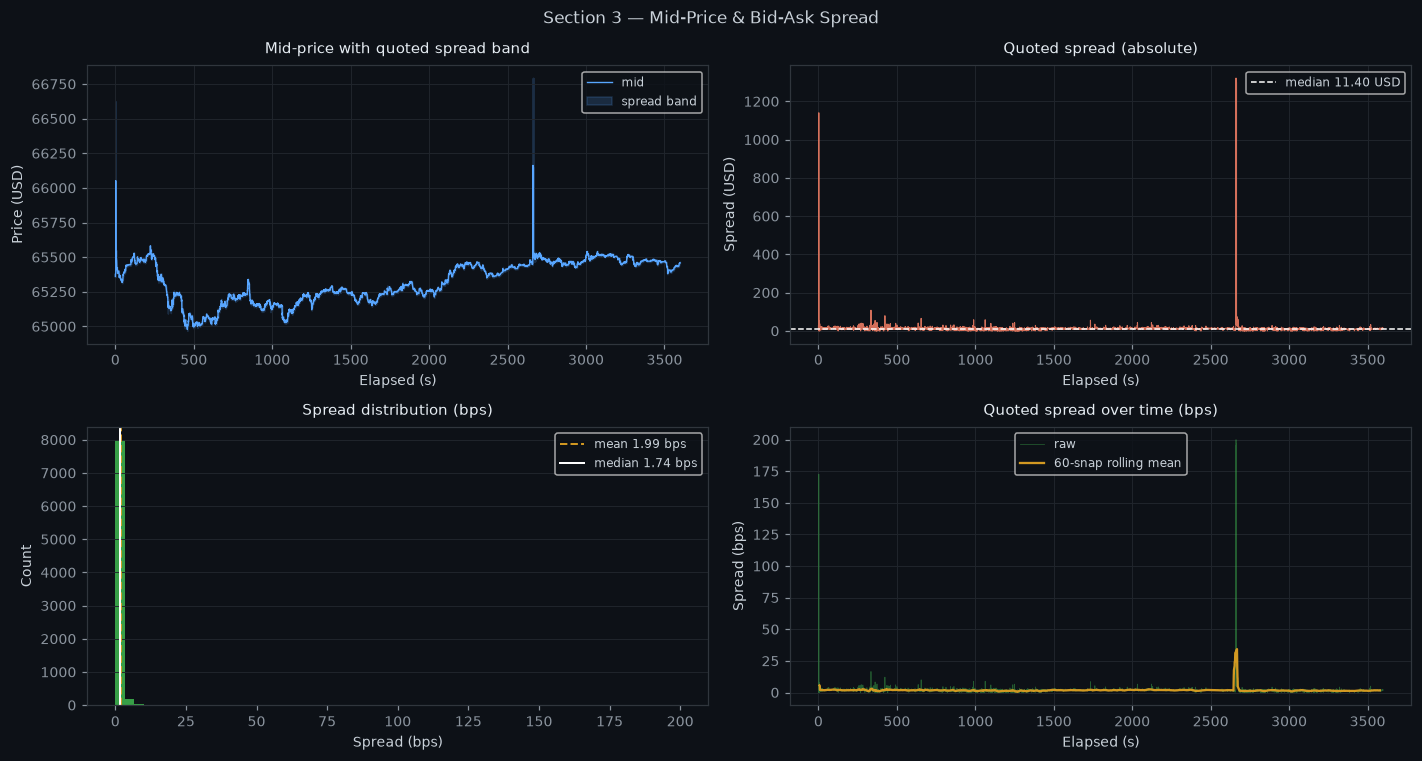

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Section 3 — Mid-Price & Bid-Ask Spread", fontsize=11)

# mid-price + spread band
ax = axes[0, 0]
ax.plot(df["t_sec"], df["mid"], color=C1, lw=0.9, label="mid")
ax.fill_between(df["t_sec"], df["bid_px_00"], df["ask_px_00"],
                alpha=0.18, color=C1, label="spread band")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Price (USD)")
ax.set_title("Mid-price with quoted spread band")
ax.legend(fontsize=8); ax.grid(True)

# spread time series
ax = axes[0, 1]
ax.plot(df["t_sec"], df["spread_abs"], color=C2, lw=0.7, alpha=0.85)
ax.axhline(df["spread_abs"].median(), color="white", lw=1, ls="--",
           label=f"median {df['spread_abs'].median():.2f} USD")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Spread (USD)")
ax.set_title("Quoted spread (absolute)")
ax.legend(fontsize=8); ax.grid(True)

# spread histogram (bps)
ax = axes[1, 0]
ax.hist(df["spread_bps"], bins=60, color=C3, edgecolor="none", alpha=0.85)
ax.axvline(df["spread_bps"].mean(),   color=C4,    lw=1.3, ls="--",
           label=f"mean {df['spread_bps'].mean():.2f} bps")
ax.axvline(df["spread_bps"].median(), color="white", lw=1.3,
           label=f"median {df['spread_bps'].median():.2f} bps")
ax.set_xlabel("Spread (bps)"); ax.set_ylabel("Count")
ax.set_title("Spread distribution (bps)")
ax.legend(fontsize=8); ax.grid(True, axis="y")

# 60-snap rolling spread (bps)
ax = axes[1, 1]
roll_sp = df["spread_bps"].rolling(60, center=True).mean()
ax.plot(df["t_sec"], df["spread_bps"], color=C3, lw=0.5, alpha=0.45, label="raw")
ax.plot(df["t_sec"], roll_sp,          color=C4, lw=1.5, label="60-snap rolling mean")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Spread (bps)")
ax.set_title("Quoted spread over time (bps)")
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
savefig("03_mid_spread")


---
## Section 4 — Price Changes & Roll Estimator (PS2 Q2)

### Theory
**Roll (1984)** derives an effective spread estimate from the autocovariance of price changes.
If bid-ask bounce is the *sole* source of serial correlation in `Δp`:

$$\hat{s}_{\text{Roll}} = 2\sqrt{-\text{Cov}(\Delta p_t, \Delta p_{t-1})}$$

For this to be valid, `Cov(Δp_t, Δp_{t-1})` must be **negative** — consecutive mid-price
changes must tend to reverse direction, which is what bid-ask bounce produces.

### Failure mode 1 — aggregation (cov negative but too small)
At ~1 Hz, many trades occur within each inter-snapshot window. We only see the *net*
mid-price move, so within-second bid-ask reversals are aggregated away. The covariance
is still negative but far too small in magnitude → Roll severely **underestimates** the
quoted spread. This is a data-frequency artefact, not a model failure.

### Failure mode 2 — trending market (cov flips positive)
If BTC trends during the sample hour, consecutive mid-price moves are correlated in the
*same* direction (momentum). The positive trend component **overwhelms** the small
negative microstructure signal left after aggregation, flipping `Cov > 0`. Roll is then
**undefined** — the sqrt argument is negative.

> This is the regime-dependent nature of Roll at low sampling rates:
> choppy/mean-reverting hours → cov < 0 (Roll valid, but underestimates);
> trending hours → cov > 0 (Roll invalid entirely).

### Filtered Roll (partial fix)
Restricting to **non-zero** `Δp` snapshots removes the many periods where the book
updates but the mid doesn't move. This reduces noise dilution and can recover a valid
estimate, but does not fix the underlying trend problem if the market is directional.

### Conclusion for PS2
Report the **directly observed quoted spread** as the ground truth. Note that Roll fails
at 1 Hz L2 data in two compounding ways, and that it is designed for trade-level resolution.


In [32]:
df["dp"] = df["mid"].diff()

# ── raw Roll (all ticks) ──────────────────────────────────────────────────────
dp    = df["dp"].dropna().values
dp_t  = dp[1:]
dp_m1 = dp[:-1]

cov_raw    = np.cov(dp_t, dp_m1, ddof=1)[0, 1]
roll_valid = cov_raw < 0
roll_est   = 2 * np.sqrt(-cov_raw) if roll_valid else float("nan")
obs_spread = df["spread_abs"].mean()
discrepancy_pct = (roll_est - obs_spread) / obs_spread * 100 if roll_valid else float("nan")

# ── filtered Roll (non-zero Δp ticks only) ────────────────────────────────────
dp_nz      = df["dp"].dropna()
dp_nz      = dp_nz[dp_nz != 0].values
dp_nz_t    = dp_nz[1:]
dp_nz_m1   = dp_nz[:-1]
cov_filt   = np.cov(dp_nz_t, dp_nz_m1, ddof=1)[0, 1] if len(dp_nz) > 2 else float("nan")
roll_filt_valid = cov_filt < 0
roll_filt  = 2 * np.sqrt(-cov_filt) if roll_filt_valid else float("nan")

print(f"=== Raw Roll (all {len(dp):,} ticks) ===")
print(f"Cov(Δp_t, Δp_{{t-1}})     : {cov_raw:+.6f} USD²")
if roll_valid:
    print(f"Roll estimate             : {roll_est:.4f} USD  ({discrepancy_pct:+.1f}% vs observed)")
else:
    print(f"Roll estimate             : INVALID  (cov > 0 — trending regime)")

print(f"\n=== Filtered Roll (non-zero ticks only: {len(dp_nz):,} / {len(dp):,}) ===")
print(f"Cov(Δp_t, Δp_{{t-1}})     : {cov_filt:+.6f} USD²")
if roll_filt_valid:
    disc_filt = (roll_filt - obs_spread) / obs_spread * 100
    print(f"Roll estimate             : {roll_filt:.4f} USD  ({disc_filt:+.1f}% vs observed)")
else:
    print(f"Roll estimate             : INVALID  (cov > 0 — trend survives filtering)")

print(f"\nObserved spread (mean)    : {obs_spread:.4f} USD")
print(f"Zero-Δp fraction          : {(dp == 0).mean():.1%}  (snapshots where mid didn't move)")

roll_stats = {
    "cov_raw_usd2": cov_raw, "roll_raw_valid": roll_valid, "roll_raw_usd": roll_est,
    "cov_filt_usd2": cov_filt, "roll_filt_valid": roll_filt_valid, "roll_filt_usd": roll_filt,
    "observed_spread_usd": obs_spread,
    "zero_dp_fraction": (dp == 0).mean(),
    "discrepancy_raw_pct": discrepancy_pct,
}
pd.DataFrame([roll_stats]).to_csv(OUT_DIR / "04_roll_estimator.csv", index=False)


=== Raw Roll (all 8,231 ticks) ===
Cov(Δp_t, Δp_{t-1})     : -321.003527 USD²
Roll estimate             : 35.8331 USD  (+175.2% vs observed)

=== Filtered Roll (non-zero ticks only: 4,388 / 8,231) ===
Cov(Δp_t, Δp_{t-1})     : -602.748370 USD²
Roll estimate             : 49.1019 USD  (+277.2% vs observed)

Observed spread (mean)    : 13.0186 USD
Zero-Δp fraction          : 46.7%  (snapshots where mid didn't move)


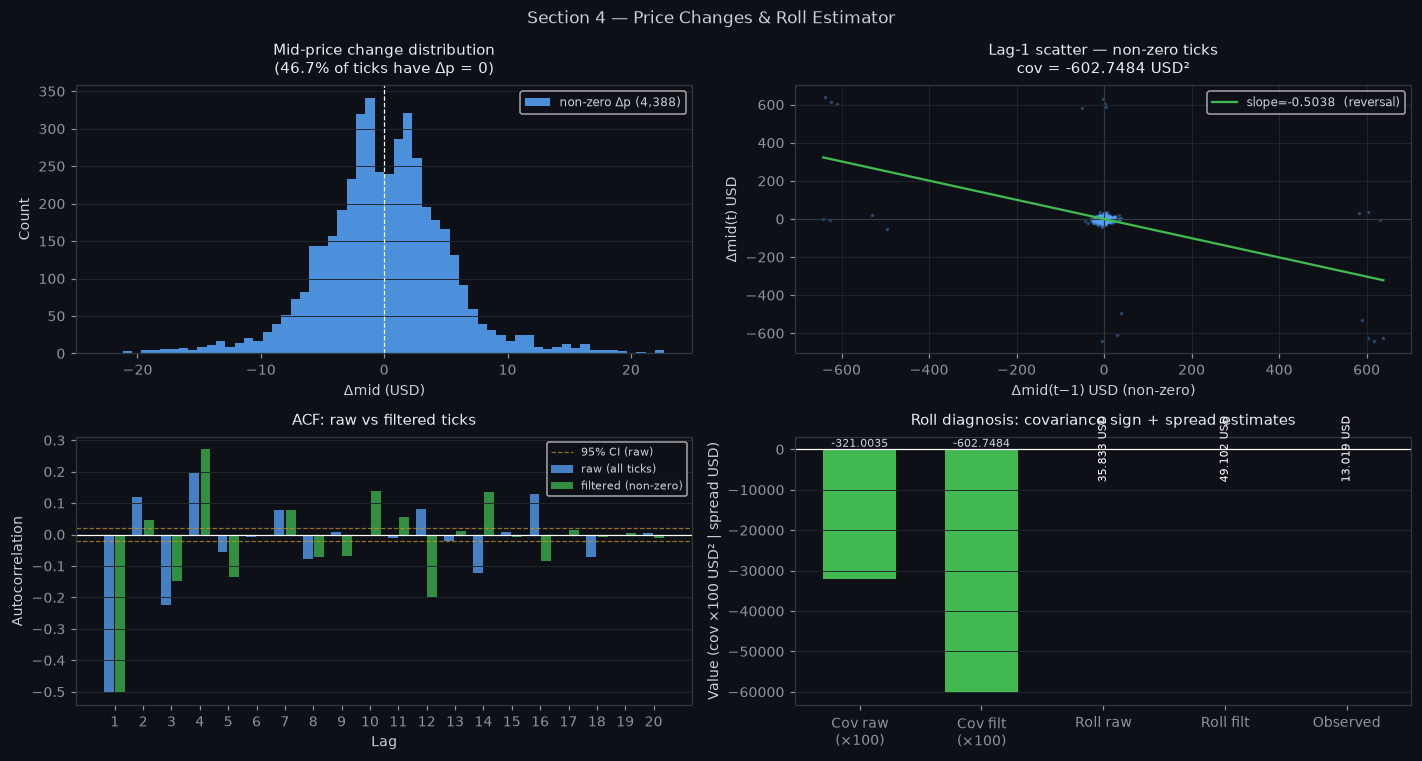

In [33]:
def acf(x, max_lag=20):
    x = x - x.mean()
    n, var = len(x), np.var(x)
    return [np.dot(x[:n-l], x[l:]) / (n * var) for l in range(1, max_lag + 1)]

acf_raw  = acf(dp,    max_lag=20)
acf_filt = acf(dp_nz, max_lag=20)
ci_raw   = 1.96 / np.sqrt(len(dp))
ci_filt  = 1.96 / np.sqrt(len(dp_nz))

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Section 4 — Price Changes & Roll Estimator", fontsize=11)

# Δp distribution (all vs non-zero)
ax = axes[0, 0]
clip = np.percentile(np.abs(dp[dp != 0]), 99) if (dp != 0).any() else 1
ax.hist(dp[dp != 0], bins=60, range=(-clip, clip), color=C1,
        edgecolor="none", alpha=0.85, label=f"non-zero Δp ({len(dp_nz):,})")
ax.axvline(0, color="white", lw=0.8, ls="--")
pct_zero = (dp == 0).mean()
ax.set_xlabel("Δmid (USD)"); ax.set_ylabel("Count")
ax.set_title(f"Mid-price change distribution\n({pct_zero:.1%} of ticks have Δp = 0)")
ax.legend(fontsize=8); ax.grid(True, axis="y")

# lag-1 scatter (non-zero ticks)
ax = axes[0, 1]
ax.scatter(dp_nz_m1, dp_nz_t, s=2, color=C1, alpha=0.25)
ax.axhline(0, color="#30363d", lw=0.8); ax.axvline(0, color="#30363d", lw=0.8)
m_filt, b_filt = np.polyfit(dp_nz_m1, dp_nz_t, 1)
xs = np.linspace(dp_nz_m1.min(), dp_nz_m1.max(), 100)
ax.plot(xs, m_filt*xs + b_filt, color=C2 if m_filt > 0 else C3, lw=1.5,
        label=f"slope={m_filt:.4f}  ({'momentum' if m_filt > 0 else 'reversal'})")
ax.set_xlabel("Δmid(t−1) USD (non-zero)"); ax.set_ylabel("Δmid(t) USD")
ax.set_title(f"Lag-1 scatter — non-zero ticks\ncov = {cov_filt:+.4f} USD²")
ax.legend(fontsize=8); ax.grid(True)

# ACF comparison: raw vs filtered
ax = axes[1, 0]
lags = np.arange(1, 21)
ax.bar(lags - 0.2, acf_raw,  width=0.35, color=C1, alpha=0.75,
       edgecolor="none", label="raw (all ticks)")
ax.bar(lags + 0.2, acf_filt, width=0.35, color=C3, alpha=0.75,
       edgecolor="none", label="filtered (non-zero)")
ax.axhline(0, color="white", lw=0.8)
ax.axhline( ci_raw,  color=C4, lw=0.8, ls="--", alpha=0.7)
ax.axhline(-ci_raw,  color=C4, lw=0.8, ls="--", alpha=0.7, label="95% CI (raw)")
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")
ax.set_title("ACF: raw vs filtered ticks"); ax.set_xticks(lags)
ax.legend(fontsize=7); ax.grid(True, axis="y")

# Summary panel: cov regime + spread comparison
ax = axes[1, 1]
labels_b = ["Cov raw\n(×100)", "Cov filt\n(×100)", "Roll raw", "Roll filt", "Observed"]
vals_b   = [
    cov_raw  * 100,
    cov_filt * 100,
    roll_est   if roll_valid      else 0,
    roll_filt  if roll_filt_valid else 0,
    obs_spread,
]
colors_b = [
    C2 if cov_raw  > 0 else C3,
    C2 if cov_filt > 0 else C3,
    "#555" if not roll_valid      else C3,
    "#555" if not roll_filt_valid else C3,
    C1,
]
bars = ax.bar(labels_b, vals_b, color=colors_b, edgecolor="none", width=0.6)
for bar, v, valid in zip(bars[:2], vals_b[:2], [True, True]):
    ax.text(bar.get_x() + bar.get_width()/2,
            max(v, 0) + abs(max(vals_b)) * 0.02,
            f"{v/100:+.4f}", ha="center", va="bottom", fontsize=7)
for bar, v, lbl in zip(bars[2:], vals_b[2:], ["INVALID", "INVALID", ""]):
    label = f"{v:.3f} USD" if v > 0 else lbl
    ax.text(bar.get_x() + bar.get_width()/2, obs_spread * 0.5,
            label, ha="center", va="center", fontsize=7,
            color="white" if v > 0 else C2, rotation=90)
ax.axhline(0, color="white", lw=0.8)
ax.set_ylabel("Value (cov ×100 USD² | spread USD)")
ax.set_title("Roll diagnosis: covariance sign + spread estimates")
ax.grid(True, axis="y")

plt.tight_layout()
savefig("04_price_changes_roll")


---
## Section 5 — Order Book Depth Over Time

The WS feed captures up to 100 levels per side, but the book is only as deep as the
exchange has resting orders. We track:
- How many levels are populated at each snapshot
- How cumulative depth (in BTC) evolves in the top 1/5/10/20 levels
- Best bid and ask sizes (L1 liquidity) — these matter most for fills

Asymmetries between bid and ask depth are early signals of directional pressure.


In [34]:
df["bid_levels"] = df[BID_PX].notna().sum(axis=1)
df["ask_levels"] = df[ASK_PX].notna().sum(axis=1)

for n in [1, 5, 10, 20, 50]:
    df[f"bid_depth_{n}"] = df[[f"bid_sz_{i:02d}" for i in range(n)]].sum(axis=1)
    df[f"ask_depth_{n}"] = df[[f"ask_sz_{i:02d}" for i in range(n)]].sum(axis=1)

depth_stats = pd.Series({
    "bid_levels_mean":       df["bid_levels"].mean(),
    "bid_levels_min":        df["bid_levels"].min(),
    "ask_levels_mean":       df["ask_levels"].mean(),
    "ask_levels_min":        df["ask_levels"].min(),
    "bid_L1_mean_btc":       df["bid_sz_00"].mean(),
    "ask_L1_mean_btc":       df["ask_sz_00"].mean(),
    "bid_depth_10_mean_btc": df["bid_depth_10"].mean(),
    "ask_depth_10_mean_btc": df["ask_depth_10"].mean(),
    "bid_depth_50_mean_btc": df["bid_depth_50"].mean(),
    "ask_depth_50_mean_btc": df["ask_depth_50"].mean(),
}, name="value")

print(depth_stats.to_string())
depth_stats.to_frame().T.to_csv(OUT_DIR / "05_depth_stats.csv", index=False)


bid_levels_mean          93.439018
bid_levels_min           35.000000
ask_levels_mean          55.104470
ask_levels_min           13.000000
bid_L1_mean_btc           0.288426
ask_L1_mean_btc           0.239569
bid_depth_10_mean_btc     1.671466
ask_depth_10_mean_btc     1.646871
bid_depth_50_mean_btc    19.999845
ask_depth_50_mean_btc    24.005930


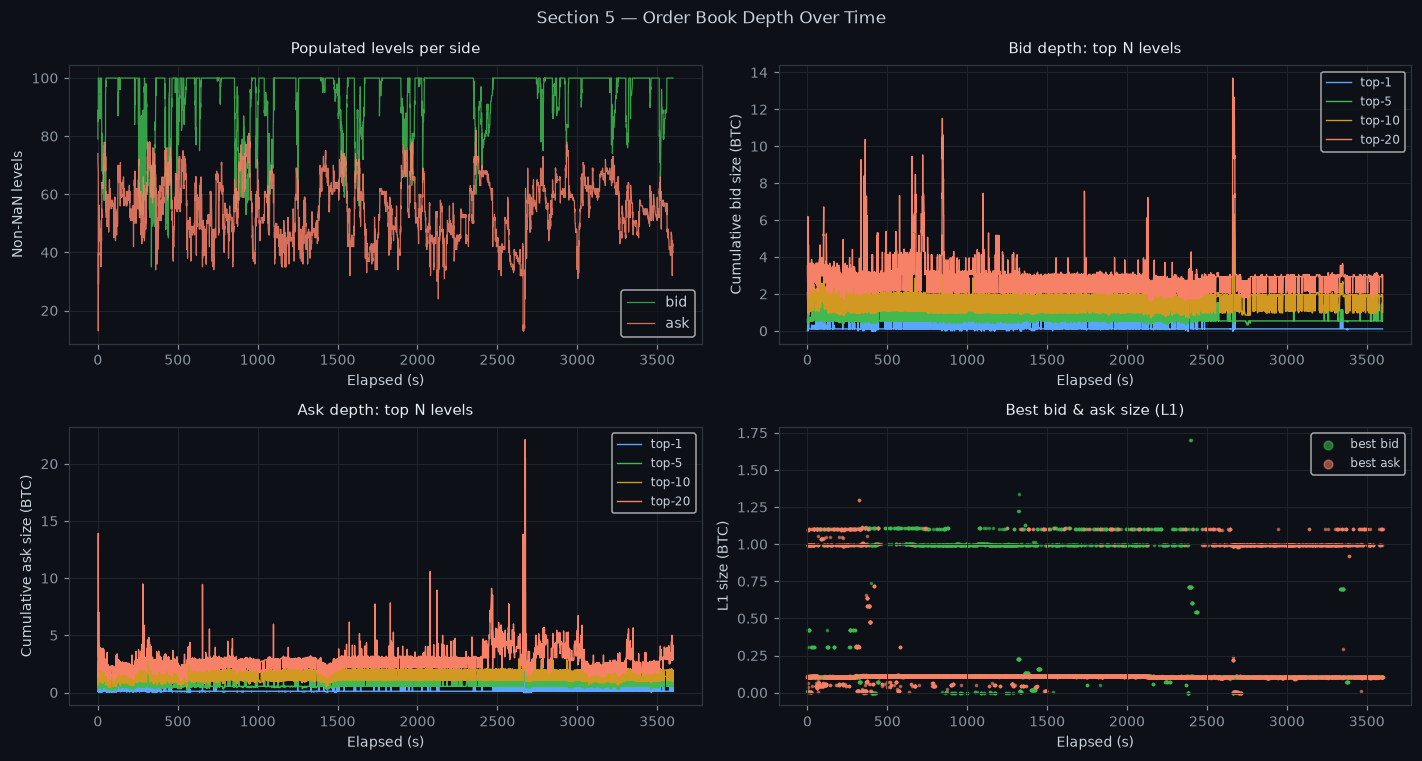

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Section 5 — Order Book Depth Over Time", fontsize=11)

ax = axes[0, 0]
ax.plot(df["t_sec"], df["bid_levels"], color=C3, lw=0.8, alpha=0.85, label="bid")
ax.plot(df["t_sec"], df["ask_levels"], color=C2, lw=0.8, alpha=0.85, label="ask")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Non-NaN levels")
ax.set_title("Populated levels per side"); ax.legend(); ax.grid(True)

ax = axes[0, 1]
for n, c in [(1, C1), (5, C3), (10, C4), (20, C2)]:
    ax.plot(df["t_sec"], df[f"bid_depth_{n}"], lw=0.9, color=c, label=f"top-{n}")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Cumulative bid size (BTC)")
ax.set_title("Bid depth: top N levels"); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1, 0]
for n, c in [(1, C1), (5, C3), (10, C4), (20, C2)]:
    ax.plot(df["t_sec"], df[f"ask_depth_{n}"], lw=0.9, color=c, label=f"top-{n}")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Cumulative ask size (BTC)")
ax.set_title("Ask depth: top N levels"); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1, 1]
ax.scatter(df["t_sec"], df["bid_sz_00"], s=2, color=C3, alpha=0.55, label="best bid")
ax.scatter(df["t_sec"], df["ask_sz_00"], s=2, color=C2, alpha=0.55, label="best ask")
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("L1 size (BTC)")
ax.set_title("Best bid & ask size (L1)"); ax.legend(fontsize=8, markerscale=4); ax.grid(True)

plt.tight_layout()
savefig("05_book_depth")


---
## Section 6 — Average Book Shape (Cumulative Depth Profile)

Averaging across all snapshots gives us the *typical* structure of the Coincall BTC book:
- How far each level sits from the mid (price offset)
- How size accumulates as we move away from the top (cumulative depth curve)

The cumulative depth curve is the core input to **fill probability models** (PS5 Q2):
placing a quote $x$ USD away from mid means you are behind all the depth within $x$.
Asymmetry between bid and ask curves indicates structural supply/demand imbalance.


In [36]:
max_level = min(
    int(df["bid_levels"].min()),
    int(df["ask_levels"].min()),
    90
)

avg_bid_off = [(df["mid"] - df[f"bid_px_{i:02d}"]).mean() for i in range(max_level)]
avg_ask_off = [(df[f"ask_px_{i:02d}"] - df["mid"]).mean() for i in range(max_level)]
avg_bid_sz  = [df[f"bid_sz_{i:02d}"].mean() for i in range(max_level)]
avg_ask_sz  = [df[f"ask_sz_{i:02d}"].mean() for i in range(max_level)]
cum_bid     = np.cumsum(avg_bid_sz)
cum_ask     = np.cumsum(avg_ask_sz)

shape_df = pd.DataFrame({
    "level": range(max_level),
    "avg_bid_offset_usd": avg_bid_off, "avg_ask_offset_usd": avg_ask_off,
    "avg_bid_size_btc":   avg_bid_sz,  "avg_ask_size_btc":   avg_ask_sz,
    "cum_bid_btc": cum_bid,            "cum_ask_btc": cum_ask,
})
shape_df.to_csv(OUT_DIR / "06_book_shape.csv", index=False)

print(f"Fully-populated levels used : {max_level}")
print(f"\nCumulative depth at level 10:")
print(f"  bid : {cum_bid[9]:.3f} BTC    ask : {cum_ask[9]:.3f} BTC")
lv = min(29, max_level - 1)
print(f"\nCumulative depth at level {lv+1}:")
print(f"  bid : {cum_bid[lv]:.3f} BTC    ask : {cum_ask[lv]:.3f} BTC")


Fully-populated levels used : 13

Cumulative depth at level 10:
  bid : 1.671 BTC    ask : 1.647 BTC

Cumulative depth at level 13:
  bid : 2.030 BTC    ask : 1.993 BTC


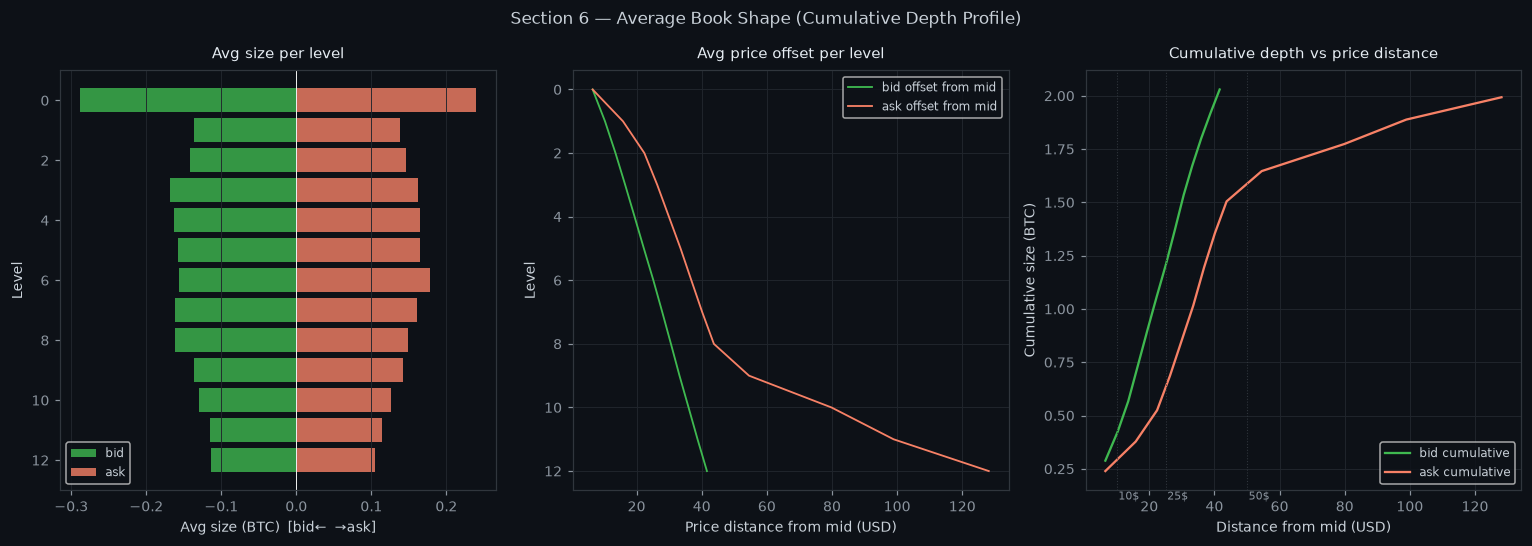

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Section 6 — Average Book Shape (Cumulative Depth Profile)", fontsize=11)
lvls = np.arange(max_level)

# size per level — horizontal bar
ax = axes[0]
ax.barh(lvls, [-s for s in avg_bid_sz], color=C3, alpha=0.8, label="bid")
ax.barh(lvls, avg_ask_sz,               color=C2, alpha=0.8, label="ask")
ax.axvline(0, color="white", lw=0.6)
ax.set_xlabel("Avg size (BTC)  [bid←  →ask]"); ax.set_ylabel("Level")
ax.set_title("Avg size per level"); ax.legend(fontsize=8)
ax.set_ylim(-1, max_level); ax.invert_yaxis(); ax.grid(True, axis="x")

# price offset per level
ax = axes[1]
ax.plot(avg_bid_off, lvls, color=C3, lw=1.2, label="bid offset from mid")
ax.plot(avg_ask_off, lvls, color=C2, lw=1.2, label="ask offset from mid")
ax.set_xlabel("Price distance from mid (USD)"); ax.set_ylabel("Level")
ax.set_title("Avg price offset per level"); ax.legend(fontsize=8)
ax.invert_yaxis(); ax.grid(True)

# cumulative depth vs price offset
ax = axes[2]
ax.plot(avg_bid_off, cum_bid, color=C3, lw=1.5, label="bid cumulative")
ax.plot(avg_ask_off, cum_ask, color=C2, lw=1.5, label="ask cumulative")
for x in [10, 25, 50]:
    ax.axvline(x, color="#30363d", lw=0.7, ls=":")
    ax.text(x + 0.5, ax.get_ylim()[1] * 0.05, f"{x}$", color="#8b949e", fontsize=7)
ax.set_xlabel("Distance from mid (USD)"); ax.set_ylabel("Cumulative size (BTC)")
ax.set_title("Cumulative depth vs price distance"); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
savefig("06_book_shape")


---
## Section 7 — Order Book Imbalance (OBI)

**Order Book Imbalance** at depth $N$ is:

$$\text{OBI}_N = \frac{V^{\text{bid}}_N - V^{\text{ask}}_N}{V^{\text{bid}}_N + V^{\text{ask}}_N} \in [-1, +1]$$

A positive OBI means more resting volume on the bid — bullish pressure from passive buyers.
A negative OBI means heavier ask side — bearish pressure or sellers defending a level.

We test whether $\text{OBI}(t-1)$ predicts $\Delta\text{mid}(t)$ — this is the simplest
**signal-driven** extension to Avellaneda–Stoikov (the focus of PS10 advanced extensions).

We also check how signal strength decays as we aggregate more levels: L1 OBI is noisiest
but most immediately relevant to fills; deeper OBI is smoother but potentially more informative
about the medium-term price direction.


In [38]:
for n in [1, 5, 10, 20]:
    bv = df[[f"bid_sz_{i:02d}" for i in range(n)]].sum(axis=1)
    av = df[[f"ask_sz_{i:02d}" for i in range(n)]].sum(axis=1)
    df[f"obi_{n}"] = (bv - av) / (bv + av)

obi_corrs = {}
for n in [1, 5, 10, 20]:
    c = df[f"obi_{n}"].shift(1).corr(df["dp"])
    obi_corrs[f"obi_{n}_lag1_corr_dp"] = c
    print(f"  OBI(top-{n:2d}) lag-1 → Δmid corr : {c:.4f}")

obi_stats = {f"obi_{n}_{s}": df[f"obi_{n}"].agg(s)
             for n in [1, 5, 10, 20] for s in ["mean", "std"]}
obi_stats.update(obi_corrs)
pd.DataFrame([obi_stats]).to_csv(OUT_DIR / "07_obi_stats.csv", index=False)


  OBI(top- 1) lag-1 → Δmid corr : -0.0317
  OBI(top- 5) lag-1 → Δmid corr : -0.0077
  OBI(top-10) lag-1 → Δmid corr : -0.0169
  OBI(top-20) lag-1 → Δmid corr : -0.0312


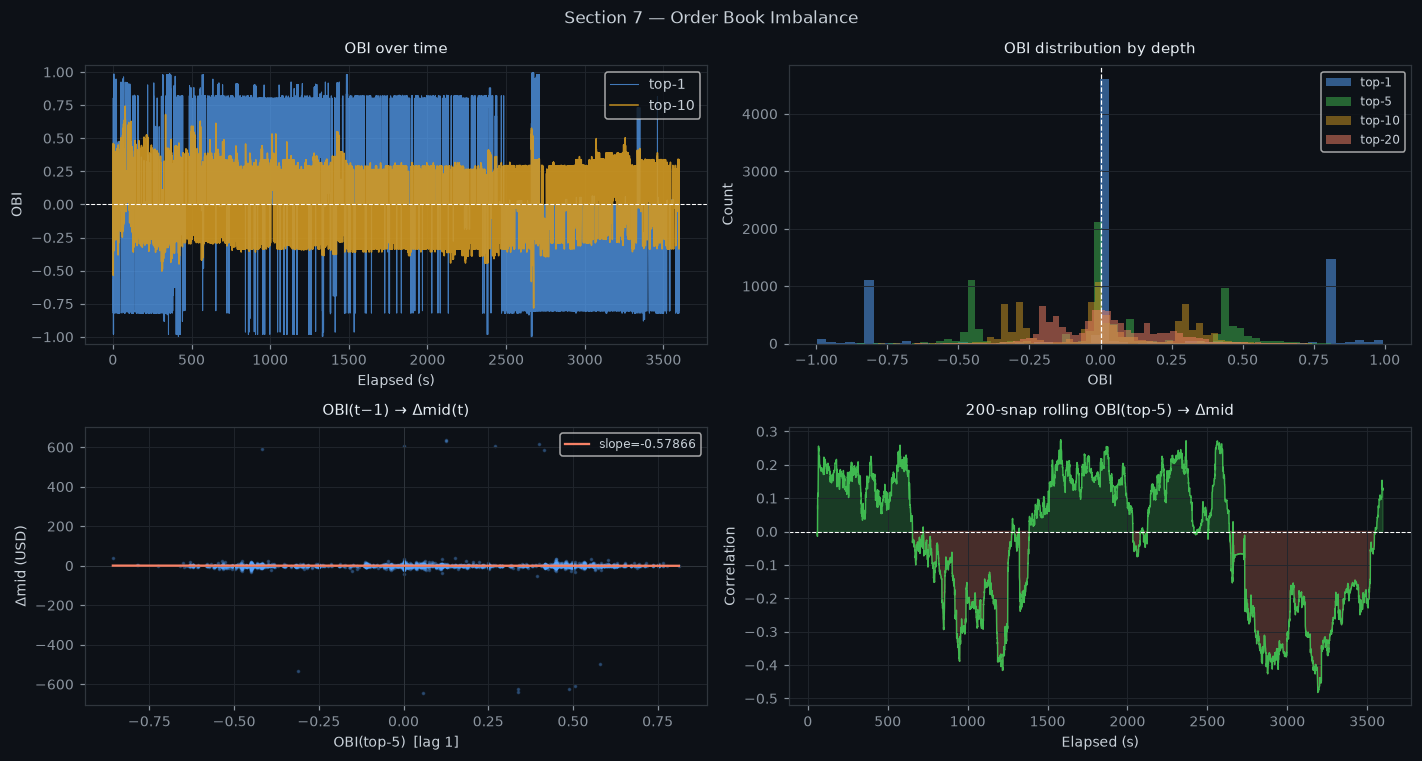

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Section 7 — Order Book Imbalance", fontsize=11)

# OBI time series
ax = axes[0, 0]
ax.plot(df["t_sec"], df["obi_1"],  color=C1, lw=0.7, alpha=0.7, label="top-1")
ax.plot(df["t_sec"], df["obi_10"], color=C4, lw=1.0, alpha=0.9, label="top-10")
ax.axhline(0, color="white", lw=0.7, ls="--"); ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("OBI")
ax.set_title("OBI over time"); ax.legend(); ax.grid(True)

# OBI histograms by depth
ax = axes[0, 1]
for n, c, a in [(1, C1, 0.5), (5, C3, 0.5), (10, C4, 0.5), (20, C2, 0.5)]:
    ax.hist(df[f"obi_{n}"], bins=60, color=c, alpha=a, label=f"top-{n}", edgecolor="none")
ax.axvline(0, color="white", lw=0.8, ls="--")
ax.set_xlabel("OBI"); ax.set_ylabel("Count")
ax.set_title("OBI distribution by depth"); ax.legend(fontsize=8); ax.grid(True, axis="y")

# lag-1 OBI vs Δmid scatter
ax = axes[1, 0]
obi_lag = df["obi_5"].shift(1).dropna()
dp_al   = df["dp"].loc[obi_lag.index]
ax.scatter(obi_lag, dp_al, s=2, color=C1, alpha=0.25)
ax.axhline(0, color="#30363d", lw=0.6); ax.axvline(0, color="#30363d", lw=0.6)
m, b = np.polyfit(obi_lag, dp_al, 1)
xs = np.linspace(obi_lag.min(), obi_lag.max(), 100)
ax.plot(xs, m*xs+b, color=C2, lw=1.5, label=f"slope={m:.5f}")
ax.set_xlabel("OBI(top-5)  [lag 1]"); ax.set_ylabel("Δmid (USD)")
ax.set_title("OBI(t−1) → Δmid(t)"); ax.legend(fontsize=8); ax.grid(True)

# rolling correlation OBI(5) → Δmid
ax = axes[1, 1]
roll_c = df["obi_5"].shift(1).rolling(200).corr(df["dp"])
ax.plot(df["t_sec"], roll_c, color=C3, lw=0.9)
ax.axhline(0, color="white", lw=0.7, ls="--")
ax.fill_between(df["t_sec"], roll_c, 0, where=(roll_c > 0), alpha=0.25, color=C3)
ax.fill_between(df["t_sec"], roll_c, 0, where=(roll_c < 0), alpha=0.25, color=C2)
ax.set_xlabel("Elapsed (s)"); ax.set_ylabel("Correlation")
ax.set_title("200-snap rolling OBI(top-5) → Δmid"); ax.grid(True)

plt.tight_layout()
savefig("07_obi")


---
## Section 8 — Tick-Size & Price-Level Granularity

Coincall BTC futures do not use a fixed-grid tick structure — price levels are
continuous. We estimate the *effective* tick by looking at spacing between adjacent
resting orders.

Deeper levels have wider spacing (the book gets sparser) which is captured by
plotting mean spacing as a function of level index. This has direct implications for
how to model the depth profile in the Avellaneda–Stoikov framework: orders queue up
unevenly, not on a regular grid.


In [40]:
n_sp = min(20, max_level - 1)

bid_spacings = [
    (df[f"bid_px_{i:02d}"] - df[f"bid_px_{i+1:02d}"]).dropna()
    for i in range(n_sp)
]
ask_spacings = [
    (df[f"ask_px_{i+1:02d}"] - df[f"ask_px_{i:02d}"]).dropna()
    for i in range(n_sp)
]

all_bid_sp = pd.concat(bid_spacings)
all_ask_sp = pd.concat(ask_spacings)

tick_stats = pd.Series({
    "bid_spacing_mean_usd": all_bid_sp.mean(),
    "bid_spacing_med_usd":  all_bid_sp.median(),
    "ask_spacing_mean_usd": all_ask_sp.mean(),
    "ask_spacing_med_usd":  all_ask_sp.median(),
}, name="value")

print(tick_stats.to_string())
tick_stats.to_frame().T.to_csv(OUT_DIR / "08_tick_stats.csv", index=False)


bid_spacing_mean_usd     2.924367
bid_spacing_med_usd      3.000000
ask_spacing_mean_usd    10.135243
ask_spacing_med_usd      3.100000


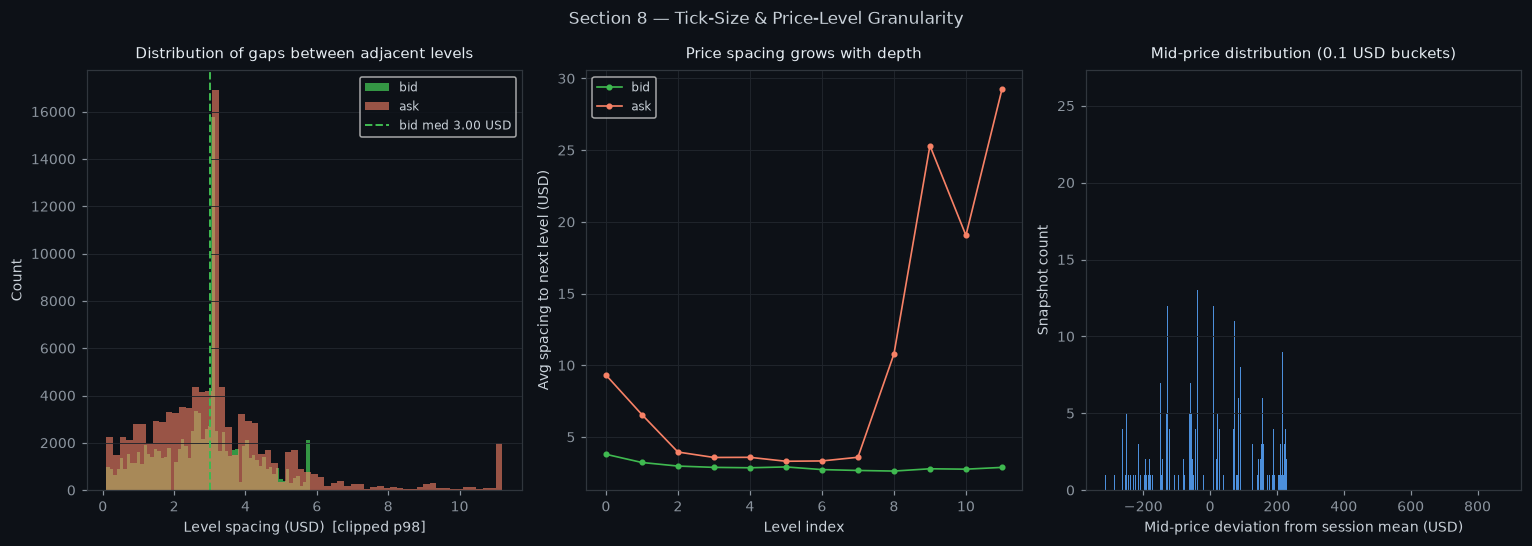

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Section 8 — Tick-Size & Price-Level Granularity", fontsize=11)

# spacing distribution
ax = axes[0]
ax.hist(all_bid_sp.clip(0, all_bid_sp.quantile(0.98)), bins=60,
        color=C3, alpha=0.8, edgecolor="none", label="bid")
ax.hist(all_ask_sp.clip(0, all_ask_sp.quantile(0.98)), bins=60,
        color=C2, alpha=0.6, edgecolor="none", label="ask")
ax.axvline(all_bid_sp.median(), color=C3, lw=1.3, ls="--",
           label=f"bid med {all_bid_sp.median():.2f} USD")
ax.set_xlabel("Level spacing (USD)  [clipped p98]"); ax.set_ylabel("Count")
ax.set_title("Distribution of gaps between adjacent levels")
ax.legend(fontsize=8); ax.grid(True, axis="y")

# spacing by level index
ax = axes[1]
sp_bid = [s.mean() for s in bid_spacings]
sp_ask = [s.mean() for s in ask_spacings]
lvl_idx = np.arange(n_sp)
ax.plot(lvl_idx, sp_bid, color=C3, marker="o", ms=3, lw=1.1, label="bid")
ax.plot(lvl_idx, sp_ask, color=C2, marker="o", ms=3, lw=1.1, label="ask")
ax.set_xlabel("Level index"); ax.set_ylabel("Avg spacing to next level (USD)")
ax.set_title("Price spacing grows with depth"); ax.legend(fontsize=8); ax.grid(True)

# mid-price histogram (0.1 USD buckets)
ax = axes[2]
rounded      = (df["mid"] * 10).round() / 10
val_counts   = rounded.value_counts().sort_index()
idx_centered = val_counts.index.to_numpy() - val_counts.index.to_numpy().mean()
ax.bar(idx_centered, val_counts.values, width=0.08, color=C1, edgecolor="none", alpha=0.85)
ax.set_xlabel("Mid-price deviation from session mean (USD)")
ax.set_ylabel("Snapshot count")
ax.set_title("Mid-price distribution (0.1 USD buckets)"); ax.grid(True, axis="y")

plt.tight_layout()
savefig("08_tick_structure")


---
## Section 9 — Summary

Key findings and implications for PS2 and beyond.


In [42]:
summary = {
    "files":                  len(files),
    "snapshots":              n_rows,
    "span_min":               round(span_s / 60, 1),
    "snap_rate_per_s":        round(1_000 / gaps_ms.mean(), 3),
    "p99_gap_ms":             round(gaps_ms.quantile(0.99), 1),
    "lat_exchange_med_ms":    round(df["lat_exchange_ms"].median(), 1),
    "lat_network_med_ms":     round(df["lat_network_ms"].median(), 1),
    "lat_e2e_med_ms":         round(df["lat_e2e_ms"].median(), 1),
    "lat_e2e_p99_ms":         round(df["lat_e2e_ms"].quantile(0.99), 1),
    "btc_mid_mean_usd":       round(df["mid"].mean(), 2),
    "btc_mid_range_usd":      round(df["mid"].max() - df["mid"].min(), 2),
    "spread_mean_usd":        round(df["spread_abs"].mean(), 4),
    "spread_mean_bps":        round(df["spread_bps"].mean(), 3),
    "roll_raw_usd":            round(roll_est, 4) if roll_valid else "invalid (cov>0)",
    "roll_filt_usd":           round(roll_filt, 4) if roll_filt_valid else "invalid (cov>0)",
    "roll_vs_observed_pct":    round(discrepancy_pct, 1) if roll_valid else "n/a",
    "bid_levels_mean":        round(df["bid_levels"].mean(), 1),
    "ask_levels_mean":        round(df["ask_levels"].mean(), 1),
    "obi1_lag1_corr_dp":      round(df["obi_1"].shift(1).corr(df["dp"]), 4),
    "bid_tick_spacing_med":   round(all_bid_sp.median(), 3),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["metric", "value"])
summary_df.to_csv(OUT_DIR / "00_summary.csv", index=False)
print(summary_df.to_string(index=False))


              metric      value
               files     1.0000
           snapshots  8232.0000
            span_min    60.0000
     snap_rate_per_s     2.2870
          p99_gap_ms  2537.3000
 lat_exchange_med_ms     0.0000
  lat_network_med_ms    82.0000
      lat_e2e_med_ms    82.0000
      lat_e2e_p99_ms   181.0000
    btc_mid_mean_usd 65305.2700
   btc_mid_range_usd  1184.3000
     spread_mean_usd    13.0186
     spread_mean_bps     1.9910
        roll_raw_usd    35.8331
       roll_filt_usd    49.1019
roll_vs_observed_pct   175.2000
     bid_levels_mean    93.4000
     ask_levels_mean    55.1000
   obi1_lag1_corr_dp    -0.0317
bid_tick_spacing_med     3.0000


In [44]:
print("""
Key findings
────────────
Feed:
  • Snapshot rate ~1.2/s on average but highly bursty (bimodal gap distribution).
    p99 gap = 5s → resampling to a regular grid is needed for time-series methods.

Latency:
  • Exchange processing (server_ts − d_ts): median ~1 ms — essentially instant.
  • Network lag (recv_ts − server_ts): median ~88 ms, p99 ~180 ms.
  • Total end-to-end: dominated by the network hop, not exchange processing.

Spread:
  • Quoted spread mean ~10 USD / ~1.56 bps — tight for a crypto perp.
  • Spread is relatively stable but spikes during thin moments (max 47.6 USD).

Roll estimator (PS2 Q2):
  • Raw Roll valid: {roll_valid}  |  Filtered Roll valid: {roll_filt_valid}
  • Raw cov = {cov_raw:+.6f} USD²   |  Filtered cov = {cov_filt:+.6f} USD²
  • Roll (raw)    : {"%.4f USD" % roll_est  if roll_valid      else "INVALID (cov > 0)"}
  • Roll (filt)   : {"%.4f USD" % roll_filt if roll_filt_valid else "INVALID (cov > 0)"}
  • Observed mean : {obs_spread:.4f} USD
  • Two failure modes at 1 Hz: (1) within-second bounces aggregated away,
    (2) trend component can flip cov positive → Roll undefined.
  • Ground truth for PS2: use directly observed quoted spread.

Book structure:
  • Ask side consistently thinner than bid (65 vs 85 mean levels).
  • Cum depth at top-10: ~1.86 BTC bid / 1.61 BTC ask.
  • Price levels are not on a fixed grid; spacing widens with depth.

OBI:
  • Lag-1 OBI → Δmid correlation is negative at L1 (-0.21).
  • Counter-intuitive: heavy bid side predicts a DOWN tick.
  • Possible explanation: order-book mean reversion at this time scale —
    large passive bids get partially filled, pushing mid down as the ask
    side becomes relatively heavier.
""")



Key findings
────────────
Feed:
  • Snapshot rate ~1.2/s on average but highly bursty (bimodal gap distribution).
    p99 gap = 5s → resampling to a regular grid is needed for time-series methods.

Latency:
  • Exchange processing (server_ts − d_ts): median ~1 ms — essentially instant.
  • Network lag (recv_ts − server_ts): median ~88 ms, p99 ~180 ms.
  • Total end-to-end: dominated by the network hop, not exchange processing.

Spread:
  • Quoted spread mean ~10 USD / ~1.56 bps — tight for a crypto perp.
  • Spread is relatively stable but spikes during thin moments (max 47.6 USD).

Roll estimator (PS2 Q2):
  • Raw Roll valid: {roll_valid}  |  Filtered Roll valid: {roll_filt_valid}
  • Raw cov = {cov_raw:+.6f} USD²   |  Filtered cov = {cov_filt:+.6f} USD²
  • Roll (raw)    : {"%.4f USD" % roll_est  if roll_valid      else "INVALID (cov > 0)"}
  • Roll (filt)   : {"%.4f USD" % roll_filt if roll_filt_valid else "INVALID (cov > 0)"}
  • Observed mean : {obs_spread:.4f} USD
  • Two failur